# Display a graph of license distribution

To use, you need a personal access token from https://open-vsx.org/user-settings/tokens.

In [1]:
import os
os.environ["ACCESS_TOKEN"] = "****"
os.environ["API_ENDPOINT"] = "https://open-vsx.org/"
import get_all_extensions
import pandas as pd
import matplotlib.pyplot as plt
import json

In [2]:
extensions = get_all_extensions.get_all_by_license()
print(extensions.keys())

Retrieved 100 extensions
Retrieved 200 extensions
Retrieved 300 extensions
Retrieved 400 extensions
Retrieved 500 extensions
Retrieved 600 extensions
Retrieved 700 extensions
Retrieved 800 extensions
Retrieved 900 extensions
Retrieved 1000 extensions
Retrieved 1100 extensions
Retrieved 1200 extensions
Retrieved 1300 extensions
Retrieved 1400 extensions
Retrieved 1500 extensions
Retrieved 1600 extensions
Retrieved 1700 extensions
Retrieved 1800 extensions
Retrieved 1900 extensions
Retrieved 2000 extensions
Retrieved 2100 extensions
Retrieved 2200 extensions
Retrieved 2300 extensions
Retrieved 2400 extensions
Retrieved 2500 extensions
Retrieved 2600 extensions
Retrieved 2700 extensions
Retrieved 2800 extensions
Retrieved 2900 extensions
Retrieved 3000 extensions
Retrieved 3100 extensions
Retrieved 3200 extensions
Retrieved 3300 extensions
Retrieved 3400 extensions
Retrieved 3500 extensions
Retrieved 3600 extensions
Retrieved 3700 extensions
Retrieved 3800 extensions
Retrieved 3900 extens

In [3]:
license_count = {
    'BSD': 0,
    'AGPL': 0,
    'GPL': 0,
    'LGPL': 0,
    'EPL': 0,
    'MIT': 0,
    'Apache': 0,
    'CC': 0,
    'MPL': 0,
    'None': 0,
    'Other': 0
}
for extension_license in extensions.keys():
    license_match = False
    for license_type in license_count.keys():
        if license_type in extension_license:
            license_match = True
            license_count[license_type] = license_count[license_type] + len(extensions[extension_license])
    if license_match is False:
        license_count['Other'] = license_count['Other'] + len(extensions[extension_license])


In [4]:
sorted_license_count = dict(sorted(license_count.items(), key=lambda item: -1 * item[1]))
print(json.dumps(sorted_license_count, indent=4))

{
    "MIT": 2575,
    "None": 766,
    "Other": 479,
    "Apache": 283,
    "GPL": 266,
    "BSD": 61,
    "EPL": 52,
    "MPL": 41,
    "LGPL": 22,
    "AGPL": 21,
    "CC": 10
}


In [5]:
labels = sorted_license_count.keys()
values = sorted_license_count.values() 
print(labels)
print(values)
df = pd.DataFrame()
df['License'] = labels
df['Count'] = values
df

dict_keys(['MIT', 'None', 'Other', 'Apache', 'GPL', 'BSD', 'EPL', 'MPL', 'LGPL', 'AGPL', 'CC'])
dict_values([2575, 766, 479, 283, 266, 61, 52, 41, 22, 21, 10])


,License,Count
0,MIT,2575
1,None,766
2,Other,479
3,Apache,283
4,GPL,266
5,BSD,61
6,EPL,52
7,MPL,41
8,LGPL,22
9,AGPL,21


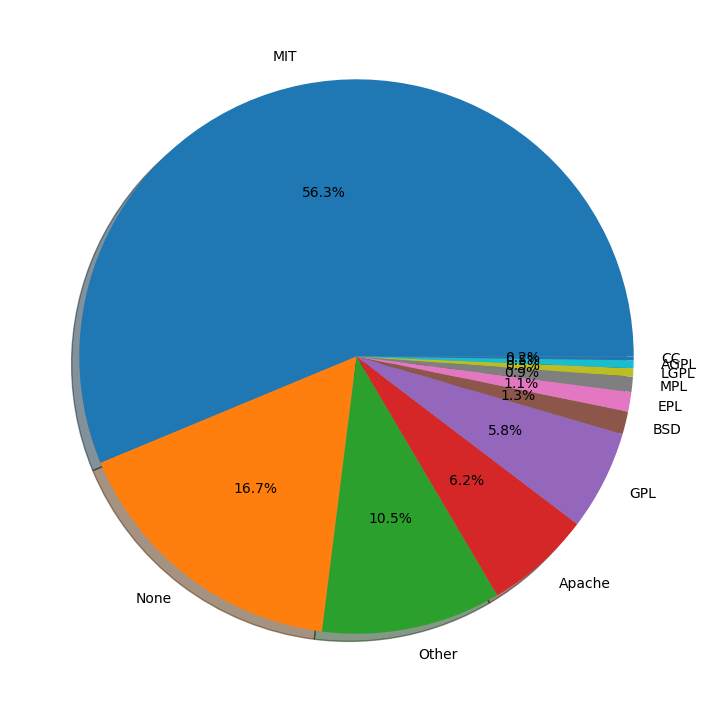

In [6]:
plt.rcParams['figure.figsize'] = (15,9)
plt.pie(values, labels=labels, shadow=True, autopct='%1.1f%%')
plt.show() 

In [7]:
extensions[0]

KeyError: 0